# Treinamento: previsão do preço do XRP/BRL

Este notebook lê o histórico diário do XRP/BRL no Mercado Bitcoin (02/01/2023 a 02/01/2026), treina **ARIMA** e **Prophet** sobre o **log do preço de fechamento**, compara os dois nos últimos 30 dias (que ficam fora do treino) e exporta o modelo vencedor para a pasta `models/`, que depois é montada no container de inferência.

> Predições experimentais, sem valor como recomendação de investimento.

In [1]:
import json
import warnings
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from prophet import Prophet
from prophet.serialize import model_to_json
from statsmodels.tsa.arima.model import ARIMA, ARIMAResults
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")

# Funciona tanto se o notebook rodar na raiz quanto dentro de training/
RAIZ = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
CSV = RAIZ / "data" / "xrp_brl_mercadobitcoin.csv"
MODELS = RAIZ / "models"
MODELS.mkdir(exist_ok=True)

DIAS_TESTE = 30
print("CSV:", CSV)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


CSV: /home/claude/xrp-previsao/data/xrp_brl_mercadobitcoin.csv


## 1. Carregar e preparar os dados

O CSV vem no formato brasileiro: datas `dd.mm.aaaa`, vírgula como separador decimal e linhas da mais recente para a mais antiga. Por isso as colunas são lidas como texto e convertidas na mão. Só a coluna `Último` (preço de fechamento) é usada.

Datas repetidas: 0
1097 dias, de 2023-01-02 até 2026-01-02


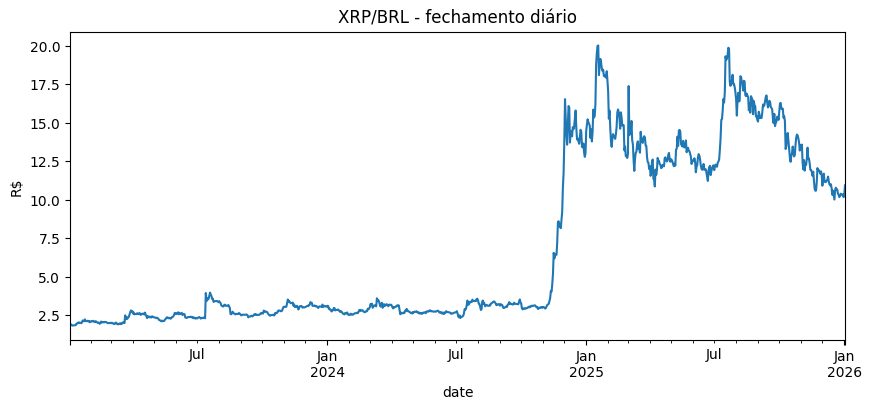

In [2]:
bruto = pd.read_csv(CSV, encoding="utf-8-sig", dtype=str)
df = pd.DataFrame({
    "date": pd.to_datetime(bruto["Data"], format="%d.%m.%Y"),
    "close": bruto["Último"].str.replace(".", "", regex=False).str.replace(",", ".").astype(float),
}).sort_values("date")
print("Datas repetidas:", df["date"].duplicated().sum())
serie = df.set_index("date")["close"].asfreq("D").ffill()  # garante 1 linha por dia
log_serie = np.log(serie)

print(f"{len(serie)} dias, de {serie.index[0].date()} até {serie.index[-1].date()}")
serie.plot(figsize=(10, 4), title="XRP/BRL - fechamento diário")
plt.ylabel("R$")
plt.show()

## 2. Estacionariedade (teste ADF)

O ARIMA precisa de uma série estacionária. O teste de Dickey-Fuller aumentado (ADF) tem como hipótese nula a presença de raiz unitária, ou seja, série **não** estacionária. Se p-valor > 0,05, não rejeitamos a hipótese nula e diferenciamos a série. Isso define o `d` do ARIMA(p, d, q).

In [3]:
p_nivel = adfuller(log_serie.dropna())[1]
p_dif = adfuller(log_serie.diff().dropna())[1]
print(f"ADF log(preço):           p-valor = {p_nivel:.4f}")
print(f"ADF diferença do log:     p-valor = {p_dif:.4f}")
D = 0 if p_nivel < 0.05 else 1
print("d escolhido =", D)

ADF log(preço):           p-valor = 0.7473
ADF diferença do log:     p-valor = 0.0000
d escolhido = 1


## 3. Separar treino e teste (últimos 30 dias)

In [4]:
treino, teste = log_serie.iloc[:-DIAS_TESTE], log_serie.iloc[-DIAS_TESTE:]
preco_real = np.exp(teste)
print("Treino até", treino.index[-1].date(), "| Teste:", teste.index[0].date(), "a", teste.index[-1].date())

def metricas(real, previsto):
    erro = real.values - previsto
    return {"MAE": float(np.mean(np.abs(erro))), "RMSE": float(np.sqrt(np.mean(erro ** 2)))}

Treino até

 2025-12-03 | Teste: 2025-12-04 a 2026-01-02


## 4. ARIMA

Testa combinações pequenas de `p` e `q` (0 a 2) com o `d` do teste ADF e escolhe a de menor **AIC**.

In [5]:
melhor_aic, melhor_ordem = np.inf, None
for p, q in product(range(3), range(3)):
    try:
        aic = ARIMA(treino, order=(p, D, q)).fit().aic
        print(f"ARIMA({p},{D},{q})  AIC = {aic:.1f}")
        if aic < melhor_aic:
            melhor_aic, melhor_ordem = aic, (p, D, q)
    except Exception as e:
        print(f"ARIMA({p},{D},{q}) falhou: {e}")

print("\nMelhor ordem:", melhor_ordem)
arima_fit = ARIMA(treino, order=melhor_ordem).fit()
prev_arima = np.exp(np.asarray(arima_fit.forecast(steps=DIAS_TESTE)))
m_arima = metricas(preco_real, prev_arima)
print("ARIMA no teste:", m_arima)

ARIMA(0,1,0)  AIC = -3750.5
ARIMA(0,1,1)  AIC = -3750.2


ARIMA(0,1,2)  AIC = -3749.1
ARIMA(1,1,0)  AIC = -3750.3
ARIMA(1,1,1)  AIC = -3749.7
ARIMA(1,1,2)  AIC = -3747.2


ARIMA(2,1,0)  AIC = -3749.2
ARIMA(2,1,1)  AIC = -3747.6


ARIMA(2,1,2)  AIC = -3750.4

Melhor ordem: (0, 1, 0)
ARIMA no teste: {'MAE': 1.0123333333333329, 'RMSE': 1.089138803520163}


## 5. Prophet

Sazonalidade anual **desligada**: com só 3 anos de dados e uma alta isolada entre nov e dez/2024 (de ~R$ 3 para ~R$ 13), o Prophet tratava essa alta como padrão de todo fim de ano e previa uma subida falsa em dezembro de 2025. Fica só a sazonalidade semanal.

In [6]:
df_prophet = treino.reset_index()
df_prophet.columns = ["ds", "y"]

prophet_fit = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=False)
prophet_fit.fit(df_prophet)
futuro = pd.DataFrame({"ds": teste.index})
prev_prophet = np.exp(prophet_fit.predict(futuro)["yhat"].values)
m_prophet = metricas(preco_real, prev_prophet)
print("Prophet no teste:", m_prophet)

18:15:41 - cmdstanpy - INFO - Chain [1] start processing


18:15:41 - cmdstanpy - INFO - Chain [1] done processing


Prophet no teste: {'MAE': 3.317273396061593, 'RMSE': 3.3415615506477407}


## 6. Comparação

Se o ARIMA escolhido for (0, 1, 0), ele é um **passeio aleatório** no log do preço: a diferença diária é tratada como ruído sem memória, e a melhor previsão para qualquer dia futuro é o último preço observado. O modelo ainda informa a incerteza, que cresce com o horizonte (variância proporcional ao número de passos).

              MAE      RMSE
ARIMA    1.012333  1.089139
Prophet  3.317273  3.341562

Modelo escolhido (menor MAE): arima


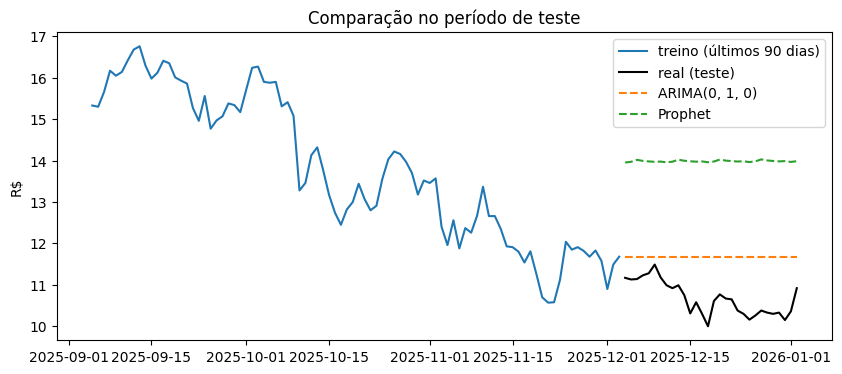

In [7]:
resultado = pd.DataFrame({"ARIMA": m_arima, "Prophet": m_prophet}).T
print(resultado)

vencedor = "arima" if m_arima["MAE"] <= m_prophet["MAE"] else "prophet"
print("\nModelo escolhido (menor MAE):", vencedor)

plt.figure(figsize=(10, 4))
plt.plot(np.exp(treino.iloc[-90:]), label="treino (últimos 90 dias)")
plt.plot(preco_real, label="real (teste)", color="black")
plt.plot(teste.index, prev_arima, "--", label=f"ARIMA{melhor_ordem}")
plt.plot(teste.index, prev_prophet, "--", label="Prophet")
plt.legend(); plt.ylabel("R$"); plt.title("Comparação no período de teste")
plt.show()

## 7. Retreinar com todos os dados e exportar

O vencedor é retreinado com a série completa, para que a previsão comece no último dia disponível. Depois salvamos:

- ARIMA: `models/arima.pkl` (`results.save`, do statsmodels)
- Prophet: `models/prophet.json` (`model_to_json`, formato recomendado pela documentação do Prophet)
- `models/metadata.json`: qual modelo venceu, ordem, métricas e última data do treino

In [8]:
# limpa artefatos antigos
for f in ["arima.pkl", "prophet.json"]:
    (MODELS / f).unlink(missing_ok=True)

if vencedor == "arima":
    final = ARIMA(log_serie, order=melhor_ordem).fit()
    final.save(MODELS / "arima.pkl")
else:
    df_full = log_serie.reset_index()
    df_full.columns = ["ds", "y"]
    final = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=False).fit(df_full)
    (MODELS / "prophet.json").write_text(model_to_json(final), encoding="utf-8")

metadata = {
    "modelo": vencedor,
    "ordem_arima": list(melhor_ordem),
    "escala": "log do preço de fechamento",
    "ultima_data_treino": str(log_serie.index[-1].date()),
    "dias_teste": DIAS_TESTE,
    "metricas_teste_brl": {"arima": m_arima, "prophet": m_prophet},
}
(MODELS / "metadata.json").write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")
print(json.dumps(metadata, indent=2, ensure_ascii=False))
print("\nArquivos em models/:", [p.name for p in MODELS.iterdir()])

{
  "modelo": "arima",
  "ordem_arima": [
    0,
    1,
    0
  ],
  "escala": "log do preço de fechamento",
  "ultima_data_treino": "2026-01-02",
  "dias_teste": 30,
  "metricas_teste_brl": {
    "arima": {
      "MAE": 1.0123333333333329,
      "RMSE": 1.089138803520163
    },
    "prophet": {
      "MAE": 3.317273396061593,
      "RMSE": 3.3415615506477407
    }
  }
}

Arquivos em models/: ['arima.pkl', 'metadata.json', '.gitkeep']


## 8. Conferir se o artefato carrega

In [9]:
if vencedor == "arima":
    carregado = ARIMAResults.load(MODELS / "arima.pkl")
    print("Previsão para amanhã (R$):", float(np.exp(np.asarray(carregado.forecast(1))[-1])))
else:
    from prophet.serialize import model_from_json
    carregado = model_from_json((MODELS / "prophet.json").read_text(encoding="utf-8"))
    amanha = pd.DataFrame({"ds": [log_serie.index[-1] + pd.Timedelta(days=1)]})
    print("Previsão para amanhã (R$):", float(np.exp(carregado.predict(amanha)["yhat"].iloc[0])))

Previsão para amanhã (R$): 10.919999999999996
